In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

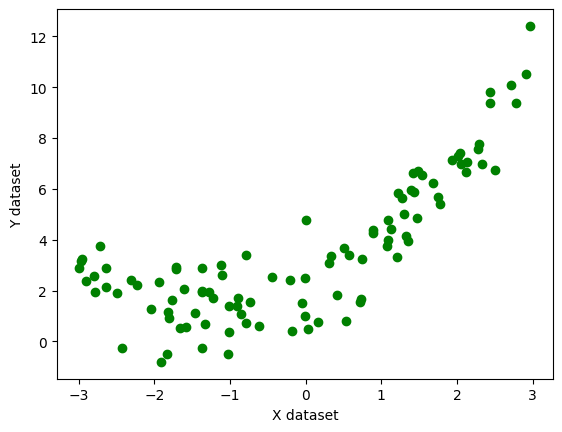

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X  + 2 + np.random.randn(100, 1)

# Quadratic equation used - y = 0.5x^2 + 1.5*x + 2 + outliers

plt.scatter(X, y, color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Lets implement Simple Linear Regression 
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [5]:
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.22639322722272381


Text(0, 0.5, 'Y')

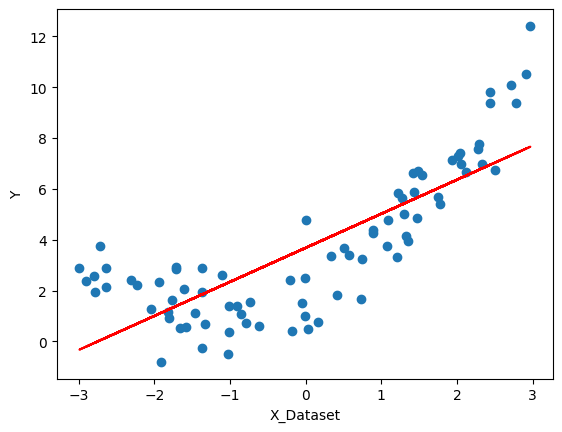

In [7]:
# Lets visualize this model
plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train)
plt.xlabel('X_Dataset')
plt.ylabel('Y')

In [8]:
# Lets Apply Polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [10]:
X_train_poly

array([[ 1.00000000e+00,  2.77355404e+00,  7.69260199e+00],
       [ 1.00000000e+00, -1.91605853e+00,  3.67128030e+00],
       [ 1.00000000e+00, -6.16965763e-01,  3.80646753e-01],
       [ 1.00000000e+00, -1.01403364e+00,  1.02826422e+00],
       [ 1.00000000e+00, -9.09749369e-01,  8.27643914e-01],
       [ 1.00000000e+00,  2.12104388e+00,  4.49882716e+00],
       [ 1.00000000e+00, -1.46845061e+00,  2.15634721e+00],
       [ 1.00000000e+00,  1.43750711e+00,  2.06642669e+00],
       [ 1.00000000e+00,  5.67969142e-01,  3.22588947e-01],
       [ 1.00000000e+00, -4.94478807e-02,  2.44509291e-03],
       [ 1.00000000e+00,  1.08667926e+00,  1.18087182e+00],
       [ 1.00000000e+00, -2.72152444e+00,  7.40669525e+00],
       [ 1.00000000e+00, -7.72771685e-03,  5.97176078e-05],
       [ 1.00000000e+00, -1.36496918e+00,  1.86314087e+00],
       [ 1.00000000e+00, -2.79400644e+00,  7.80647200e+00],
       [ 1.00000000e+00, -1.57948203e+00,  2.49476349e+00],
       [ 1.00000000e+00,  2.33112979e+00

In [11]:
X_test_poly

array([[ 1.        , -2.96207288,  8.77387576],
       [ 1.        , -0.45091447,  0.20332386],
       [ 1.        , -1.36971224,  1.87611162],
       [ 1.        , -1.83959291,  3.38410206],
       [ 1.        , -0.79336922,  0.62943472],
       [ 1.        ,  0.71840479,  0.51610544],
       [ 1.        , -1.28319385,  1.64658645],
       [ 1.        , -1.1174339 ,  1.24865852],
       [ 1.        , -0.89182239,  0.79534718],
       [ 1.        , -2.97042466,  8.82342267],
       [ 1.        ,  1.68575427,  2.84176747],
       [ 1.        ,  1.12087095,  1.25635169],
       [ 1.        , -1.22897268,  1.51037385],
       [ 1.        ,  2.12620603,  4.5207521 ],
       [ 1.        , -2.49514496,  6.22574836],
       [ 1.        ,  1.09035508,  1.1888742 ],
       [ 1.        ,  1.39574891,  1.94811502],
       [ 1.        ,  0.53525747,  0.28650056],
       [ 1.        ,  0.31073002,  0.09655315],
       [ 1.        , -2.42956853,  5.90280323]])

In [12]:
from sklearn.metrics import r2_score
regression_1.fit(X_train_poly, y_train)
y_pred = regression_1.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.6191169074006069


In [13]:
print(regression_1.coef_)

[[0.         1.35500355 0.56811969]]


In [14]:
print(regression_1.intercept_)

[2.00090019]


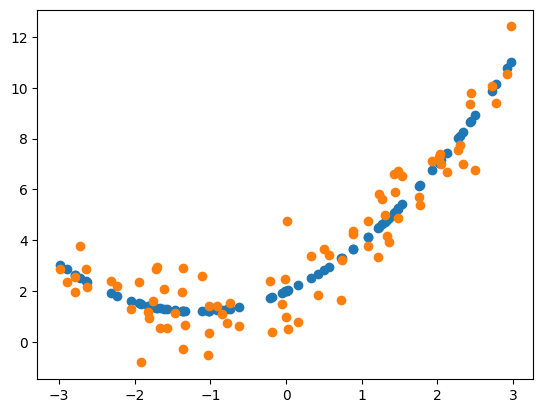

In [15]:
plt.scatter(X_train, regression_1.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [16]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [17]:
X_train_poly

array([[ 1.00000000e+00,  2.77355404e+00,  7.69260199e+00,
         2.13358473e+01],
       [ 1.00000000e+00, -1.91605853e+00,  3.67128030e+00,
        -7.03438795e+00],
       [ 1.00000000e+00, -6.16965763e-01,  3.80646753e-01,
        -2.34846014e-01],
       [ 1.00000000e+00, -1.01403364e+00,  1.02826422e+00,
        -1.04269451e+00],
       [ 1.00000000e+00, -9.09749369e-01,  8.27643914e-01,
        -7.52948529e-01],
       [ 1.00000000e+00,  2.12104388e+00,  4.49882716e+00,
         9.54220983e+00],
       [ 1.00000000e+00, -1.46845061e+00,  2.15634721e+00,
        -3.16648938e+00],
       [ 1.00000000e+00,  1.43750711e+00,  2.06642669e+00,
         2.97050305e+00],
       [ 1.00000000e+00,  5.67969142e-01,  3.22588947e-01,
         1.83220567e-01],
       [ 1.00000000e+00, -4.94478807e-02,  2.44509291e-03,
        -1.20904663e-04],
       [ 1.00000000e+00,  1.08667926e+00,  1.18087182e+00,
         1.28322892e+00],
       [ 1.00000000e+00, -2.72152444e+00,  7.40669525e+00,
      

In [18]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.6114469130259543


In [19]:
# Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

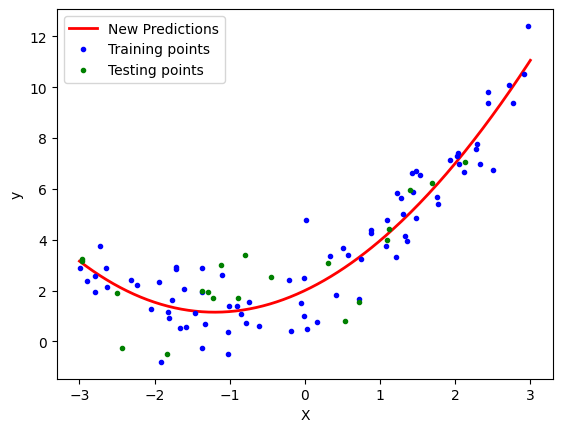

In [20]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="New Predictions")
plt.plot(X_train, y_train, "b.", label="Training points")
plt.plot(X_test, y_test, "g.", label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Pipeline Concept

In [21]:
from sklearn.pipeline import Pipeline

In [22]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])
    poly_regression.fit(X_train, y_train)   # polynomial and fit of linear regression
    y_pred_new = poly_regression.predict(X_new)  # prediction of new data set
    
    # Plotting the results
    plt.plot(X_new, y_pred_new, 'r', label="Degree " + str(degree), linewidth=2) 
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

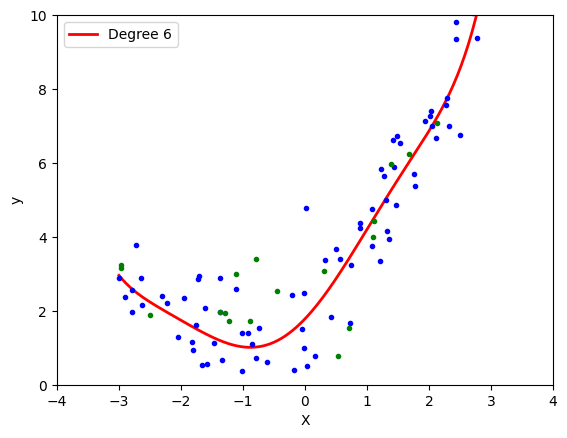

In [23]:
poly_regression(6)